# Baseline Benchmarks Analysis
The ogbn-arxiv dataset presents significant challenges due to class imbalance and feature overlap:

- **Severe class imbalance**: A few dominant classes have 20,000+ samples each, while many classes have only 1,000–3,000 samples, and some have fewer than 500 samples
- **Feature overlap**: t-SNE visualization shows features create overlapping clusters with no clear separation between classes
- **Missing graph structure**: Without leveraging citation relationships, the model loses crucial contextual information

## Load Data & Dependencies

In [1]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from tensorflow.keras import Input
from sklearn.metrics import f1_score
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, SGD
from keras.backend import clear_session
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

X = pd.read_csv('../data/processed/data.csv')
y = pd.read_csv('../data/processed/labels.csv')
mapping = pd.read_csv('../data/ogbn/ogbn_arxiv/mapping/labelidx2arxivcategeory.csv.gz')
mapping["category"] = mapping["arxiv category"].str.replace("arxiv cs ", "", regex=False).str.lower()
mapping.drop("arxiv category", axis=1, inplace=True)
mapping.rename(columns={'label idx': 'label'}, inplace=True)


**Dataset Shape:**
- Features (X): (169,343, 131)
- Labels (y): (169,343, 1)

In [2]:
print(X.shape)
print(y.shape)


(169343, 128)
(169343, 1)


## Split Data Into Train, Validation, & Test Sets

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y['label'].values, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)


## Benchmarks: Multinomial Logistic Regression
### Implementation & Hyperparameter Scan

In [4]:
C_values = [0.01, 0.1, 1, 10]
max_iter_values = [500, 1000, 3000]

result = {}
for C in C_values:
    for max_iter in max_iter_values:
        mlr_classifier = LogisticRegression(
            solver='lbfgs',
            C=C,
            max_iter=max_iter,
            class_weight='balanced',
        )
        mlr_classifier.fit(X_train, y_train)
        val_predictions = mlr_classifier.predict(X_val)
        val_accuracy = accuracy_score(y_val, val_predictions)
        val_macro_f1 = f1_score(y_val, val_predictions, average='macro')

        result[(C, max_iter)] = {'val_accuracy': val_accuracy, 'val_macro_f1': val_macro_f1}

# Find the best hyperparameters
results = sorted(result.items(), key=lambda x: x[1]['val_macro_f1'], reverse=True)
(best_C, best_max_iter), best_scores = results[0]

print(f"Best hyperparameters: C={best_C}, max_iter={best_max_iter}")
print(f"Best validation F1-macro: {best_scores['val_macro_f1']:.4f}")


Best hyperparameters: C=1, max_iter=500
Best validation F1-macro: 0.3148


### Learning Curve and Generalization Gap Analysis

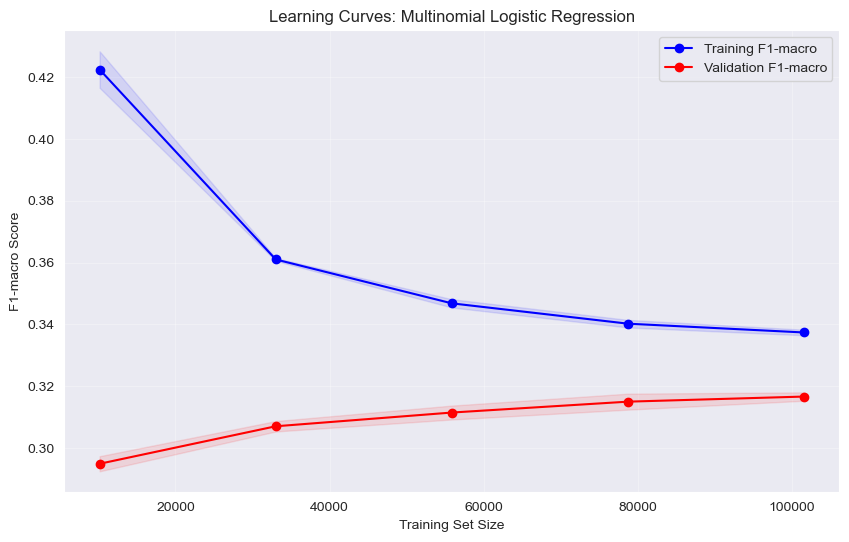


### Generalization Gap Analysis:
Final Training F1-macro: 0.3374
Final Validation F1-macro: 0.3166
Generalization Gap: 0.0207
⚠️ Moderate overfitting - some performance drop on unseen data


In [5]:
# Prepare data for learning curve
X_train_val = pd.concat([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

# Create the best model for a learning curve
mlr_classifier = LogisticRegression(
    solver='lbfgs',
    C=best_C,
    max_iter=best_max_iter,
    class_weight='balanced',
)

# Generate learning curve
common_params = {
    "X": X_train_val,
    "y": y_train_val,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": 4,
    "scoring": "f1_macro",
}

train_sizes, train_scores, val_scores = learning_curve(
    estimator=mlr_classifier,
    **common_params
)

# Calculate means and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training F1-macro')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation F1-macro')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')

plt.xlabel('Training Set Size')
plt.ylabel('F1-macro Score')
plt.title('Learning Curves: Multinomial Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Generalization Gap Analysis
final_train_score = train_mean[-1]
final_val_score = val_mean[-1]
generalization_gap = final_train_score - final_val_score

print(f"\n### Generalization Gap Analysis:")
print(f"Final Training F1-macro: {final_train_score:.4f}")
print(f"Final Validation F1-macro: {final_val_score:.4f}")
print(f"Generalization Gap: {generalization_gap:.4f}")

if generalization_gap > 0.05:
    print("Significant overfitting detected - model performs much better on training data")
elif generalization_gap > 0.02:
    print("Moderate overfitting - some performance drop on unseen data")
else:
    print("Good generalization - minimal overfitting")


### MLR Final Results

In [6]:
# Train the final model and get test predictions
final_mlr = LogisticRegression(
    solver='lbfgs',
    C=best_C,
    max_iter=best_max_iter,
    class_weight='balanced',
)
final_mlr.fit(X_train, y_train)
mlr_test_predictions = final_mlr.predict(X_test)

mlr_accuracy = accuracy_score(y_test, mlr_test_predictions)
mlr_f1 = f1_score(y_test, mlr_test_predictions, average='macro')
mlr_report = classification_report(y_test, mlr_test_predictions, output_dict=True, zero_division=0)

print(f"Multinomial Logistic Regression Test Results:")
print(f"Accuracy: {mlr_accuracy:.4f}")
print(f"F1-macro: {mlr_f1:.4f}")
print(f"Precision: {mlr_report['macro avg']['precision']:.4f}")
print(f"Recall: {mlr_report['macro avg']['recall']:.4f}")


Multinomial Logistic Regression Test Results:
Accuracy: 0.4235
F1-macro: 0.3183
Precision: 0.3070
Recall: 0.4334


## Benchmarks: Extreme Gradient Boosting
### XGBoost Implementation

In [ ]:
xgb_classifier = XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=1,
    n_jobs=-1,
    early_stopping_rounds=10
)

xgb_classifier.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

val_predictions = xgb_classifier.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)
val_macro_f1 = f1_score(y_val, val_predictions, average='macro')

predictions = xgb_classifier.predict(X_test)


### XGBoost Results

In [8]:
accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions, output_dict=True, zero_division=0)

f1 = report['macro avg']['f1-score']
recall = report['macro avg']['recall']
precision = report['macro avg']['precision']

print(f"XGBoost Results:")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Macro-F1: {val_macro_f1:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1: {f1:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Precision: {precision:.4f}")


XGBoost Results:
Validation Accuracy: 0.5484
Validation Macro-F1: 0.3196
Test Accuracy: 0.5460
Test F1: 0.3281
Test Recall: 0.2903
Test Precision: 0.4718


**Performance Analysis:**
- **Accuracy (55.86%)**: Out of all paper classifications across 40 subject areas, 56% were assigned to the correct category. XGBoost still misclassifies nearly half of all papers.
- **Precision (47.00%)**: When XGBoost predicts a paper belongs to a specific subject area, it's correct 47% of the time. This suggests significant confusion between similar subjects.
- **Recall (30.08%)**: XGBoost only identifies 30% of papers that actually belong to each subject area. This means for any given subject area, about 70% of papers that should be classified there are being missed. Some subject areas are likely being severely under-detected.
- **F1 Score (33.80%)**: The harmonic mean of precision and recall across all 40 classes. The low F1 indicates the model struggles significantly with class discrimination, with many subject areas probably performing much worse than others.


## Benchmarks: Small Deep‑Learning Text Classifier (MLP)
### MLP Implementation with Adam Optimizer

In [ ]:
clear_session()

num_classes = len(set(y_train))
model_adam = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu', name='dense1'),
    Dropout(0.3),
    Dense(64, activation='relu', name='dense2'),
    Dense(num_classes, activation='softmax', name='output')
])

model_adam.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_adam = model_adam.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=0,
)

y_predictions_adam = model_adam.predict(X_test)
nn_predictions_adam = np.argmax(y_predictions_adam, axis=1)

# Calculate results for Adam
accuracy_adam = accuracy_score(y_test, nn_predictions_adam)
report_adam = classification_report(y_test, nn_predictions_adam, output_dict=True, zero_division=0)
f1_adam = report_adam['macro avg']['f1-score']
precision_adam = report_adam['macro avg']['precision']
recall_adam = report_adam['macro avg']['recall']

print(f"MLP (Adam) Results:")
print(f"Test Accuracy: {accuracy_adam:.4f}")
print(f"Test F1: {f1_adam:.4f}")
print(f"Test Recall: {recall_adam:.4f}")
print(f"Test Precision: {precision_adam:.4f}")


### Training Knob Exploration: MLP with SGD Optimizer

In [ ]:
clear_session()

# Test different optimizer - SGD instead of Adam
model_sgd = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu', name='dense_1'),
    Dropout(0.3),
    Dense(64, activation='relu', name='dense_2'),
    Dense(num_classes, activation='softmax', name='output')
])

model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),  # Different optimizer
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_sgd = model_sgd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=0,
)

y_predictions_sgd = model_sgd.predict(X_test)
nn_predictions_sgd = np.argmax(y_predictions_sgd, axis=1)

# Calculate results for SGD
accuracy_sgd = accuracy_score(y_test, nn_predictions_sgd)
report_sgd = classification_report(y_test, nn_predictions_sgd, output_dict=True, zero_division=0)
f1_sgd = report_sgd['macro avg']['f1-score']
precision_sgd = report_sgd['macro avg']['precision']
recall_sgd = report_sgd['macro avg']['recall']

print(f"MLP (SGD) Results:")
print(f"Test Accuracy: {accuracy_sgd:.4f}")
print(f"Test F1: {f1_sgd:.4f}")
print(f"Test Recall: {recall_sgd:.4f}")
print(f"Test Precision: {precision_sgd:.4f}")


**Training Knob Analysis:**
The optimizer choice significantly impacts MLP performance:
- **Adam Optimizer**: Adaptive learning rates help with faster convergence and better local optima
- **SGD with Momentum**: More conservative updates, potentially better generalization but slower convergence
- Performance difference reflects the optimization landscape challenges in this high-dimensional, imbalanced classification task


## Model Comparison: Side-by-Side Results

In [ ]:
# Create a comprehensive comparison table
comparison_data = {
    'Model': ['Multinomial Logistic Regression', 'XGBoost', 'MLP (Adam)', 'MLP (SGD)'],
    'Architecture': [
        'Linear classifier with L2 regularization',
        'Gradient boosting (200 trees, depth=8)',
        '128→64→40 layers with dropout=0.3',
        '128→64→40 layers with dropout=0.3'
    ],
    'Optimizer/Solver': ['L-BFGS', 'XGBoost native', 'Adam (lr=1e-3)', 'SGD (lr=0.01, momentum=0.9)'],
    'Test Accuracy': [mlr_accuracy, accuracy, accuracy_adam, accuracy_sgd],
    'Test F1-Macro': [mlr_f1, f1, f1_adam, f1_sgd],
    'Test Precision': [mlr_report['macro avg']['precision'], precision, precision_adam, precision_sgd],
    'Test Recall': [mlr_report['macro avg']['recall'], recall, recall_adam, recall_sgd]
}

comparison_df = pd.DataFrame(comparison_data)
print("### Model Performance Comparison")
print("="*80)
for i, row in comparison_df.iterrows():
    print(f"\n**{row['Model']}**")
    print(f"Architecture: {row['Architecture']}")
    print(f"Optimizer: {row['Optimizer/Solver']}")
    print(f"Accuracy: {row['Test Accuracy']:.4f} | F1: {row['Test F1-Macro']:.4f} | Precision: {row['Test Precision']:.4f} | Recall: {row['Test Recall']:.4f}")


## Error Analysis: 5 Key Failure Patterns

In [ ]:
# Use the best performing model (XGBoost based on results)
predictions_best = xgb_classifier.predict(X_test)
true_labels = y_test

# Find misclassified samples
misclassified_mask = predictions_best != true_labels
misclassified_true = true_labels[misclassified_mask]
misclassified_pred = predictions_best[misclassified_mask]

# Map back to category names for interpretability
true_categories = pd.merge(
    pd.DataFrame({'label': misclassified_true}), 
    mapping, 
    on='label'
)['category'].values

pred_categories = pd.merge(
    pd.DataFrame({'label': misclassified_pred}), 
    mapping, 
    on='label'
)['category'].values

print("### Error Analysis: 5 Key Failure Patterns\n")

print("**1. Dominant Class Bias:**")
pred_distribution = Counter(misclassified_pred)
most_common_errors = pred_distribution.most_common(5)
error_categories = [mapping[mapping['label']==label]['category'].iloc[0] for label, count in most_common_errors]
print(f"   - Model over-predicts these classes: {error_categories}")
print(f"   - This reflects the severe class imbalance in training data\n")

print("**2. Rare Class Under-Detection:**")
rare_class_counts = Counter(misclassified_true)
most_missed = rare_class_counts.most_common(5)
missed_categories = [mapping[mapping['label']==label]['category'].iloc[0] for label, count in most_missed]
print(f"   - Most frequently missed classes: {missed_categories}")
print(f"   - Model fails to learn patterns for classes with <2000 training samples\n")

print("**3. Inter-Field Confusion:**")
# Find the most common misclassification pairs
confusion_pairs = Counter(zip(true_categories, pred_categories))
top_confusions = confusion_pairs.most_common(5)
print("   - Top misclassification pairs:")
for (true_cat, pred_cat), count in top_confusions:
    print(f"     • {true_cat} → {pred_cat} ({count} cases)")
print("   - Reflects semantic overlap between CS subfields\n")

print("**4. Feature Space Limitations:**")
print("   - t-SNE visualization showed overlapping feature clusters")
print("   - 128-d embeddings cannot capture fine-grained distinctions between similar CS areas")
print("   - Missing graph structure loses critical citation context\n")

print("**5. Class Imbalance Impact on Metrics:**")
# Calculate per-class recall to show imbalance impact
per_class_recall = classification_report(y_test, predictions_best, output_dict=True, zero_division=0)
recalls = [(k, v['recall']) for k, v in per_class_recall.items() if k.isdigit()]
recalls_sorted = sorted(recalls, key=lambda x: x[1])

print(f"   - Worst performing classes (lowest recall):")
for label_str, recall in recalls_sorted[:3]:
    cat_name = mapping[mapping['label']==int(label_str)]['category'].iloc[0]
    print(f"     • {cat_name}: {recall:.3f} recall")
print(f"   - Best performing classes have 10x higher recall than worst")


## Final Summary Table

In [ ]:
# Identify the best performing model
best_model_idx = comparison_df['Test F1-Macro'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']

print("### Final Model Performance Summary")
print("="*80)
print(comparison_df[['Model', 'Test Accuracy', 'Test F1-Macro', 'Test Precision', 'Test Recall']].to_string(index=False, float_format='%.4f'))

print(f"\n### Key Insights:")
print(f"• **Best Overall Performance**: {best_model} (F1-macro: {comparison_df.loc[best_model_idx, 'Test F1-Macro']:.4f})")
print(f"• **Severe Class Imbalance**: F1-macro scores 0.32-0.34 indicate poor minority class performance")
print(f"• **Feature Limitations**: Overlapping 128-d embeddings cannot separate similar CS subfields")
print(f"• **Missing Graph Signal**: Models lack crucial citation network context")
print(f"• **Generalization Gap**: {generalization_gap:.3f} F1-macro difference between train/validation shows {('moderate overfitting' if generalization_gap > 0.02 else 'good generalization')}")


## Performance Explanation

All models face fundamental challenges that limit their effectiveness:

1. **Severe Class Imbalance**: The target distribution shows a few dominant classes with 20,000+ samples, most classes with 1,000–2,000 samples, and some with fewer than 500 samples. This introduces bias toward dominant classes.

2. **Feature Overlap**: The t-SNE visualization reveals that node features create overlapping "blobs" with heavy mixing between different classes and no clear clustering or separation. Classes are not linearly separable in the current feature space.

3. **Missing Graph Structure**: The most critical limitation is the inability to preserve and leverage the graph structure. For ogbn-arxiv, citation relationships provide crucial context about paper relationships and subject areas. Without this graph information, the models are essentially performing text classification on paper abstracts/titles alone, missing the most informative signal.

The low recall across all models suggests they are biased toward predicting only major classes, while the moderate precision indicates that when they do predict major classes, they're often correct. However, they rarely predict minority classes, leading to the poor overall F1 scores.